In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
df = sns.load_dataset('tips')
print("--- Data Types ---")
print(df.dtypes)
numerical   = df.select_dtypes(include=['number']).columns.tolist()
categorical = df.select_dtypes(include=['category', 'object']).columns.tolist()

print('\nNumerical  :', numerical)
print('Categorical:', categorical)


--- Data Types ---
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [5]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [6]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


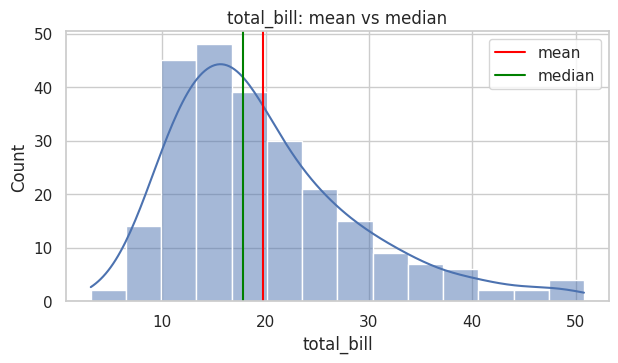

In [ ]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

In [8]:
numerical   = df.select_dtypes(include=['number']).columns.tolist()
categorical = df.select_dtypes(include=['category', 'object']).columns.tolist()

print("--- Column Classification ---")
print('Numerical Columns  :', numerical)
print('Categorical Columns:', categorical)
tip_mean = df['tip'].mean()
print(f"\n--- Mean of Numerical Column ---")
print(f"Mean of 'tip': {tip_mean:.2f}")
print(f"\n--- Value Counts of Categorical Column ---")
print(df['sex'].value_counts())


--- Column Classification ---
Numerical Columns  : ['total_bill', 'tip', 'size']
Categorical Columns: ['sex', 'smoker', 'day', 'time']

--- Mean of Numerical Column ---
Mean of 'tip': 3.00

--- Value Counts of Categorical Column ---
sex
Male      157
Female     87
Name: count, dtype: int64


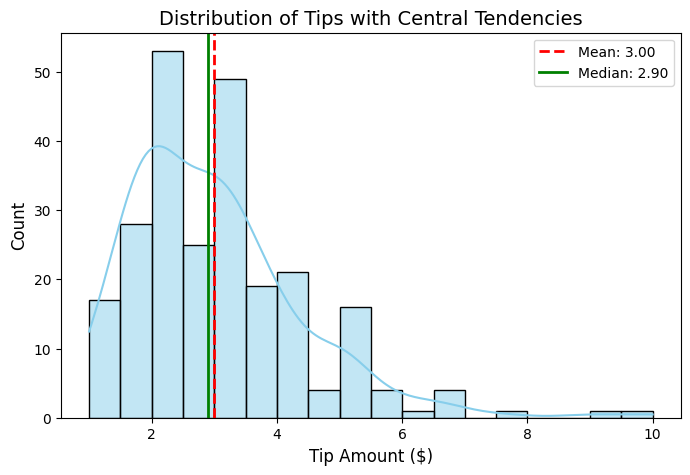

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

tip = df['tip']
tip_mean = tip.mean()
tip_median = tip.median()
plt.figure(figsize=(8, 5))
sns.histplot(tip, kde=True, color='skyblue')

plt.axvline(tip_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {tip_mean:.2f}')
plt.axvline(tip_median, color='green', linestyle='-', linewidth=2, label=f'Median: {tip_median:.2f}')
plt.title('Distribution of Tips with Central Tendencies', fontsize=14)
plt.xlabel('Tip Amount ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()


In [13]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [14]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [15]:
tip = df['tip']

tip_range = tip.max() - tip.min()
tip_variance = tip.var()
tip_std = tip.std()

print("--- Basic Dispersion Measures ---")
print(f"Range:              {tip_range:.4f}")
print(f"Variance:           {tip_variance:.4f}")
print(f"Standard Deviation: {tip_std:.4f}")

q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)
iqr = q3 - q1

print(f"\n--- Percentiles & IQR ---")
print(f"Q1 (25th percentile): {q1:.4f}")
print(f"Q3 (75th percentile): {q3:.4f}")
print(f"IQR:                  {iqr:.4f}")

# 3. Most robust measure of spread = IQR
# The IQR is the most robust measure of spread against outliers.
# Why: Range, variance, and standard deviation rely heavily on extreme values (variance/std even square the distances).
# IQR only looks at the middle 50% of the dataset (between the 25th and 75th percentiles),
# completely ignoring extreme tails and outliers on both ends.




--- Basic Dispersion Measures ---
Range:              9.0000
Variance:           1.9145
Standard Deviation: 1.3836

--- Percentiles & IQR ---
Q1 (25th percentile): 2.0000
Q3 (75th percentile): 3.5625
IQR:                  1.5625


In [16]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


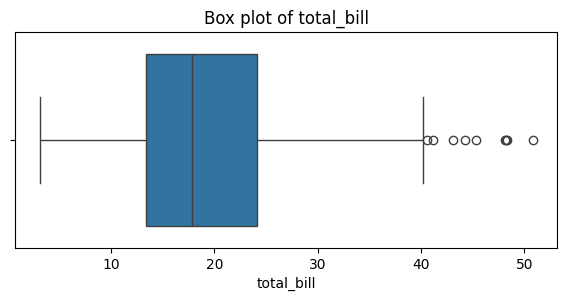

In [17]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

--- Five-Number Summary ---
Min: 1.0000
Q1:  2.0000
Q2:  2.9000
Q3:  3.5625
Max: 10.0000

Skewness: 1.4655


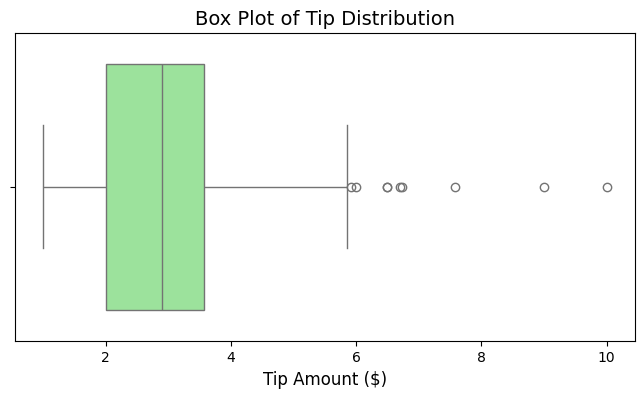

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

tip = df['tip']

five_num = tip.describe(percentiles=[0.25, 0.50, 0.75])
print("--- Five-Number Summary ---")
print(f"Min: {five_num['min']:.4f}")
print(f"Q1:  {five_num['25%']:.4f}")
print(f"Q2:  {five_num['50%']:.4f}")
print(f"Q3:  {five_num['75%']:.4f}")
print(f"Max: {five_num['max']:.4f}")
skewness = tip.skew()
print(f"\nSkewness: {skewness:.4f}")

plt.figure(figsize=(8, 4))
sns.boxplot(x=tip, color='lightgreen')

plt.title('Box Plot of Tip Distribution', fontsize=14)
plt.xlabel('Tip Amount ($)', fontsize=12)
plt.show()


In [19]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


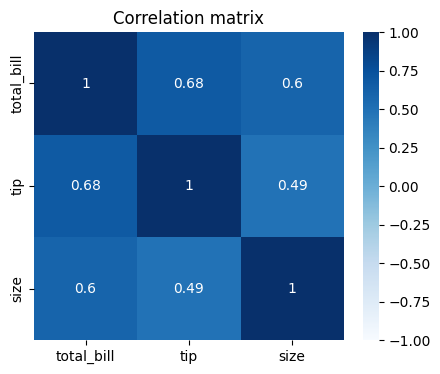

In [20]:

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [21]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


--- Correlation Matrix ---
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00



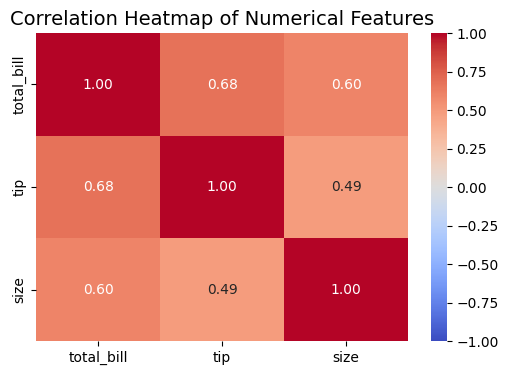

--- Summary Statistics (df.describe) ---
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_df = df.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()

print("--- Correlation Matrix ---")
print(corr_matrix.round(2))
print()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

print("--- Summary Statistics (df.describe) ---")
print(df.describe())

